In [6]:
from sklearn.datasets import load_iris
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from six import StringIO
import pydotplus
from IPython.display import display,Image

In [7]:
# max_depth
# 参考值10~100,建议设置为3(如果只是测试算法)

In [8]:
iris=load_iris()
x=iris.data  #数据特征
y=iris.target#数据标签
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
scaler=preprocessing.StandardScaler().fit(x_train)
x1_train=scaler.transform(x_train)
x1_test=scaler.transform(x_test)

In [9]:
clf=DecisionTreeClassifier(criterion='entropy') #信息增益
# 可以改成gini进行对比
# clf=DecisionTreeClassifier(criterion='gini') #信息增益
clf.fit(x_train,y_train)
y_pre=clf.predict(x1_test)
print(clf.score(x1_test,y_test))

0.36666666666666664


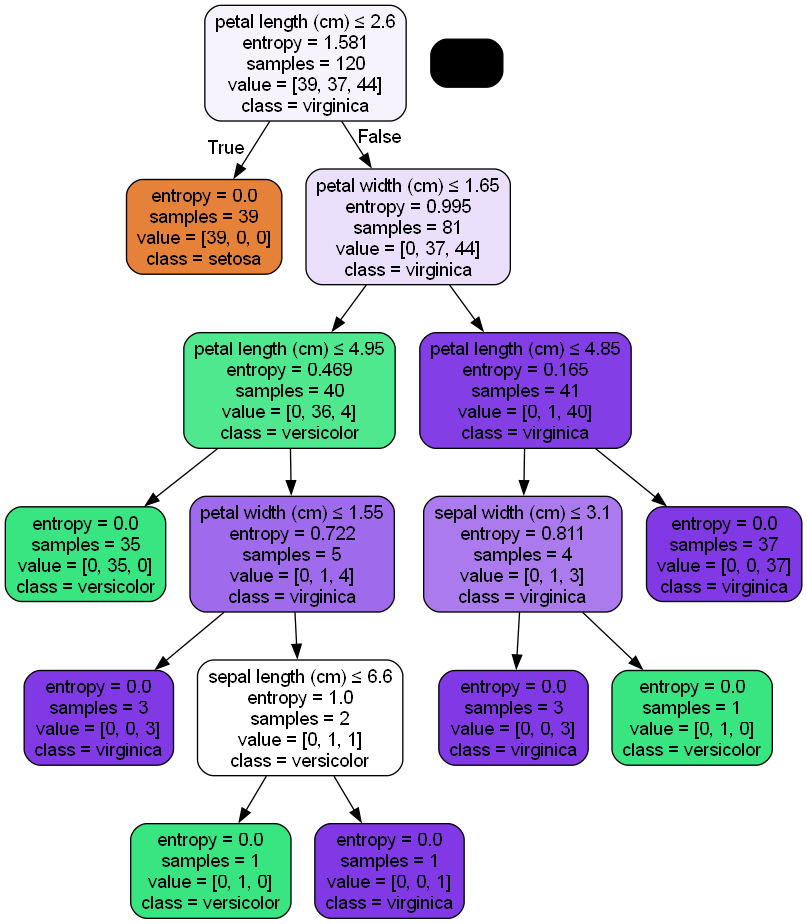

In [10]:
import os
os.environ["PATH"] += os.pathsep + r"E:\Software\Graphviz-14.0.4-win32\bin"
dot_data=StringIO()
export_graphviz(clf,out_file=dot_data,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               filled=True,rounded=True,
               special_characters=True)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('iris_entropy.png')
# 图片名字
display(Image(graph.create_png()))

# # 很多图片->封装在一个pdf文档中
# graph.write_pdf('iris.pdf')